# Garbage Classification (Multimodal: Image + Text)
This notebook trains and evaluates a **multimodal** classifier using:
- **Image**: ResNet-18 backbone
- **Text**: DistilBERT encoder
- **Fusion**: concatenation of embeddings → MLP → 4-way classification

Dataset layout (TALC):
```
garbage_data/
  CVPR_2024_dataset_Train/{Black,Blue,Green,TTR}/*.jpg
  CVPR_2024_dataset_Val/{Black,Blue,Green,TTR}/*.jpg
  CVPR_2024_dataset_Test/{Black,Blue,Green,TTR}/*.jpg
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 1. Setup

In [ ]:
# Standard library imports
import os
import re
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple

# Deep learning setup
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Image handling
from PIL import Image
from torchvision import transforms, models

# Text models
from transformers import DistilBertModel, DistilBertTokenizerFast
from tqdm import tqdm

# Evaluation and plotting
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


## 2. Config


In [ ]:
# Using a dataclass to cleanly store hyperparameters and paths
# to keep organizationa and help make tuning easier

@dataclass
class Config:
  # Dataset locations
  train_path: str
  val_path: str
  test_path: str

  # Training parameters
  img_size: int = 224 # Image resolution (ResNet default is 224x224)
  max_len: int = 150 # Max token length for BERT input
  batch_size: int = 16
  epochs: int = 5
  lr: float = 2e-4 # Learning rate
  weight_decay: float = 1e-4
  num_workers: int = 2

  # Transfer learning technique(prevent overfitting)
  freeze_resnet: bool = True

  # Compute device preference
  device: str = "cuda"

# If CUDA is available use GPU, otherwise fallback to CPU
def get_device(preferred="cuda"):
    return torch.device("cuda" if preferred == "cuda" and torch.cuda.is_available() else "cpu")

# Config to TALC
#cfg = Config(
#    train_path="/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Train",
#    val_path="/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Val",
#    test_path="/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Test",
#    epochs=5,
#    batch_size=16,
#)

# Config to drive dataset
cfg = Config(
    train_path="/content/drive/MyDrive/CVPR_2024_dataset_Train",
    val_path="/content/drive/MyDrive/CVPR_2024_dataset_Val",
    test_path="/content/drive/MyDrive/CVPR_2024_dataset_Test",
)

device = get_device(cfg.device)
print("Device:", device)


Device: cuda


## 3. Utilities

In [ ]:
# Setting all random seeds to ensure reproducibility
def set_seed(seed: int = 42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed(42)

# Convert the filename to text and clean text
def filename_to_text(file_name: str) -> str:
  """Convert `greasy_pizza_box.jpg` -> 'greasy pizza box' (and strip digits)."""
  stem = os.path.splitext(os.path.basename(file_name))[0]
  text = stem.replace("_", " ")
  text = re.sub(r"\d+", "", text)
  return text.strip()

# Detecting class folders automatically to get label
def list_class_folders(split_path: str) -> List[str]:
  """Detect class folders dynamically (e.g., Black/Blue/Green/TTR)."""
  classes = sorted([
    d for d in os.listdir(split_path)
    if os.path.isdir(os.path.join(split_path, d))
  ])
  if len(classes) == 0:
    raise RuntimeError(f"No class folders found in: {split_path}")
  return classes

# Make sure we only load valid image formats
def is_image_file(fn: str) -> bool:
  return fn.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"))


## 4. Dataset
Loads images from folder structure and tokenizes text derived from filenames.

In [ ]:
# Load images, extract text from file name, tokenize text
# return everthing together

class MultimodalDataset(Dataset):
  def __init__(self, split_path: str, tokenizer, max_len: int, img_transform):
    self.split_path = split_path # Path to train val test foler
    self.tokenizer = tokenizer # BERT tokenizer
    self.max_len = max_len # Max token length
    self.img_transform = img_transform # Torchvision transforms

    self.class_names = list_class_folders(split_path) # Detect class names
    self.label_map = {cls: i for i, cls in enumerate(self.class_names)} # Map class names to int
    self.idx_to_label = {i: cls for cls, i in self.label_map.items()} # Reverse map for later visualization

    # Store (filepath, label). Walk through each class folder
    self.samples: List[Tuple[str, int]] = []
    for cls in self.class_names:
      cls_dir = os.path.join(split_path, cls)
      for fn in os.listdir(cls_dir):
        fp = os.path.join(cls_dir, fn)
        if os.path.isfile(fp) and is_image_file(fn):
          self.samples.append((fp, self.label_map[cls]))

    if len(self.samples) == 0:
      raise RuntimeError(f"No images found under: {split_path}")

  # Number of samples in dataset
  def __len__(self):
    return len(self.samples)

  # Returns one training example
  def __getitem__(self, idx: int):
    fp, label = self.samples[idx]
    fn = os.path.basename(fp)

    # Image
    img = Image.open(fp).convert("RGB")
    img = self.img_transform(img)

    # Text derived from filename
    text = filename_to_text(fn)

    enc = self.tokenizer(
        text,
        add_special_tokens=True,
        max_length=self.max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    return {
        "image": img,
        "input_ids": enc["input_ids"].squeeze(0),
        "attention_mask": enc["attention_mask"].squeeze(0),
        "label": torch.tensor(label, dtype=torch.long),
        "text": text,
        "filename": fn,
        "path": fp,
    }


## 5. Transforms + DataLoaders

In [ ]:
# Load pretrained tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Training transforms including data augmentation
train_tf = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Validation and test transformers (NO augmentation)
eval_tf = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = MultimodalDataset(cfg.train_path, tokenizer, cfg.max_len, train_tf)
val_ds   = MultimodalDataset(cfg.val_path,   tokenizer, cfg.max_len, eval_tf)
test_ds  = MultimodalDataset(cfg.test_path,  tokenizer, cfg.max_len, eval_tf)



# Use train_ds class order for display
class_names = train_ds.class_names
print("Detected classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))


Detected classes: ['Black', 'Blue', 'Green', 'TTR']
Train/Val/Test sizes: 56 56 56


## 6. Model (ResNet18 + DistilBERT + Fusion Head)

In [ ]:
class MultimodalClassifier(nn.Module):
  def __init__(self, num_classes: int, freeze_resnet: bool = True, fusion_hidden: int = 256):
    super().__init__()

    # Image encoder: ResNet-18
    self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    img_dim = self.resnet.fc.in_features # Get dimension before classification layer
    self.resnet.fc = nn.Identity() # remove final classifier

    # Freeze weights if set
    if freeze_resnet:
      for p in self.resnet.parameters():
        p.requires_grad = False

    # Text encoder: DistilBERT
    self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
    txt_dim = self.bert.config.hidden_size

    # Fusion classifier
    self.head = nn.Sequential(
        nn.Linear(img_dim + txt_dim, fusion_hidden),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(fusion_hidden, num_classes),
    )

  def forward(self, image, input_ids, attention_mask):
    # Extract image features
    img_feat = self.resnet(image)  # (B, img_dim)

    # Extract text features
    bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    txt_feat = bert_out.last_hidden_state[:, 0, :]  # (B, txt_dim)

    # Concatenate image and text
    z = torch.cat([img_feat, txt_feat], dim=1)
    return self.head(z)

model = MultimodalClassifier(num_classes=len(class_names), freeze_resnet=cfg.freeze_resnet).to(device)
print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 57.4MB/s]


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

## 7. Train / Eval helpers

In [ ]:
# Training loop for standard PyTorch
# Zero gradients, forward, compute loss, backward, update
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="train", leave=False):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images, input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="eval", leave=False):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(images, input_ids, attention_mask)
        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / max(len(loader), 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds_all = []
    labels_all = []
    paths_all = []
    texts_all = []

    for batch in tqdm(loader, desc="predict", leave=False):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(images, input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        preds_all.extend(preds.tolist())
        labels_all.extend(batch["label"].numpy().tolist())
        paths_all.extend(batch["path"])
        texts_all.extend(batch["text"])

    return np.array(preds_all), np.array(labels_all), paths_all, texts_all


## 8. Training loop (save best model by validation loss)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_val_loss = float("inf")
best_path = "best_multimodal.pth"

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(cfg.epochs):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{cfg.epochs} | train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
        print("Saved best checkpoint:", best_path)

print("Best val loss:", best_val_loss)


Epoch 1/5 | train_loss=1.3520 | val_loss=1.2531 | val_acc=0.5179
Saved best checkpoint: best_multimodal.pth


Epoch 2/5 | train_loss=1.0754 | val_loss=1.0415 | val_acc=0.5000
Saved best checkpoint: best_multimodal.pth


Epoch 3/5 | train_loss=0.6989 | val_loss=0.9017 | val_acc=0.6071
Saved best checkpoint: best_multimodal.pth


Epoch 4/5 | train_loss=0.3855 | val_loss=0.8460 | val_acc=0.6250
Saved best checkpoint: best_multimodal.pth


Epoch 5/5 | train_loss=0.1782 | val_loss=0.9043 | val_acc=0.6607
Best val loss: 0.8460083454847336


## 9. Plot training curves

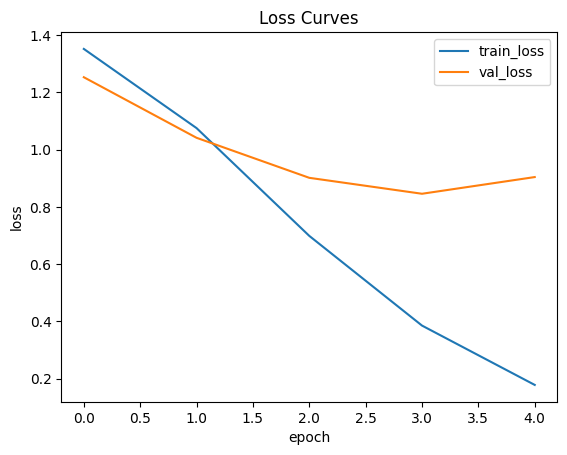

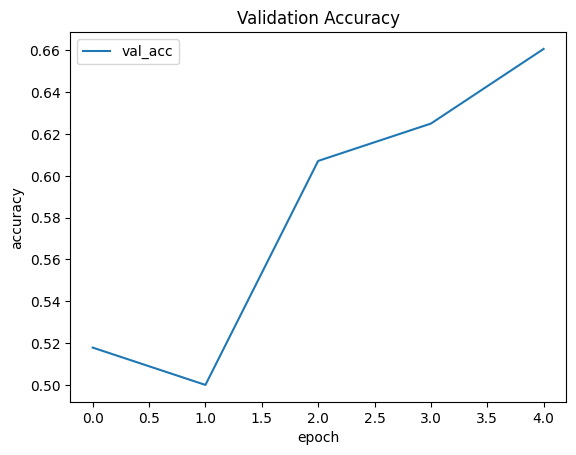

In [ ]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()


## 10. Test evaluation + confusion matrix + classification report

Test accuracy: 0.5535714285714286

Classification report:
              precision    recall  f1-score   support

       Black     0.3529    0.4286    0.3871        14
        Blue     0.4706    0.5714    0.5161        14
       Green     0.7333    0.7857    0.7586        14
         TTR     0.8571    0.4286    0.5714        14

    accuracy                         0.5536        56
   macro avg     0.6035    0.5536    0.5583        56
weighted avg     0.6035    0.5536    0.5583        56



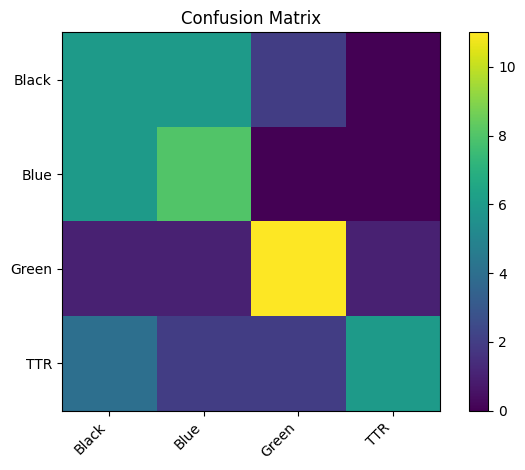

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))

preds, labels, paths, texts = predict(model, test_loader, device)

test_acc = (preds == labels).mean()
print("Test accuracy:", test_acc)

print("\nClassification report:")
print(classification_report(labels, preds, target_names=class_names, digits=4))

cm = confusion_matrix(labels, preds)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


## 11. Misclassifications


Misclassified: 25 out of 56


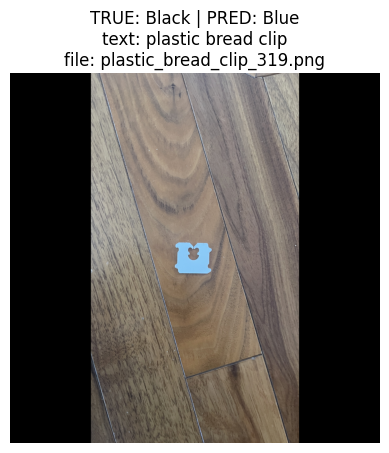

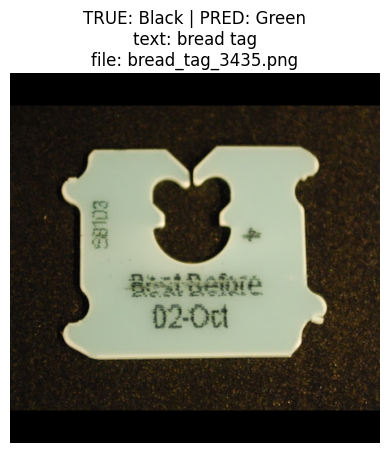

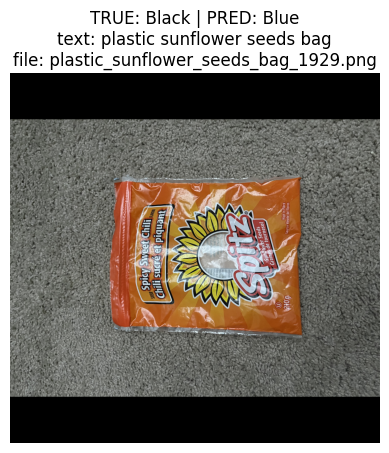

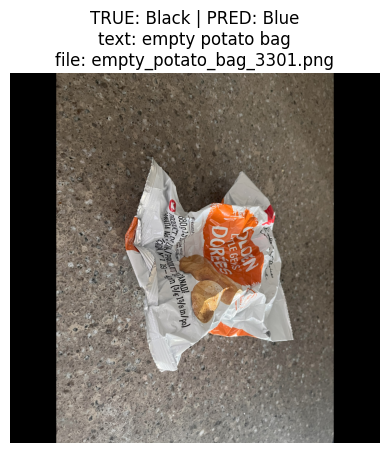

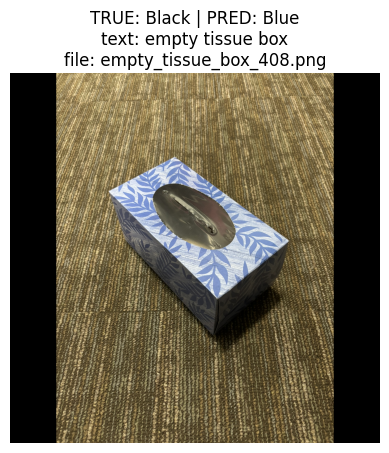

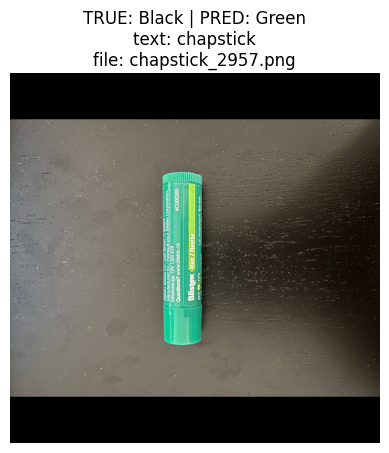

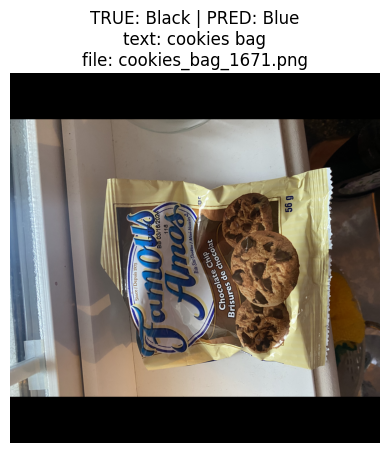

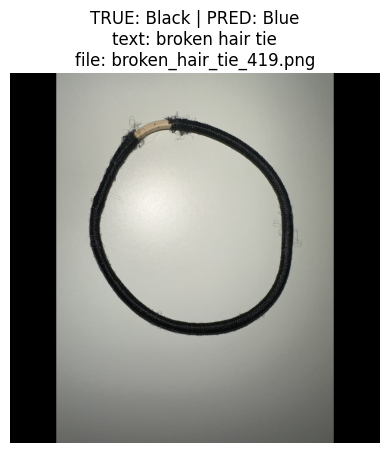

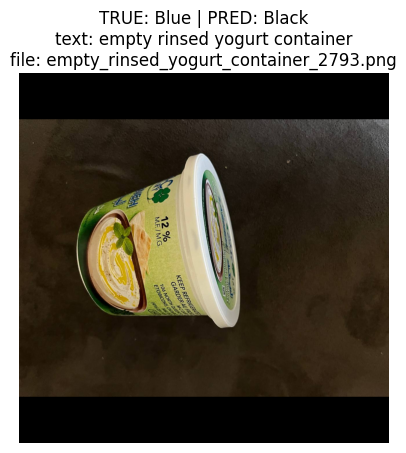

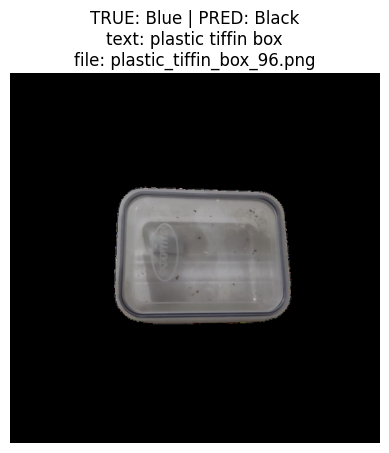

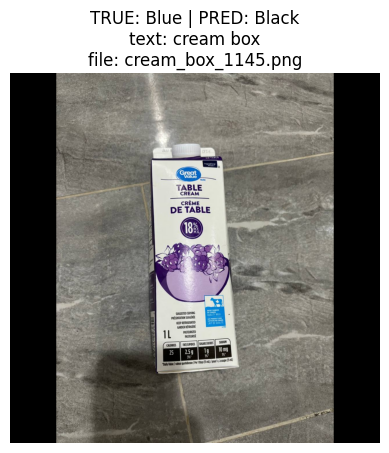

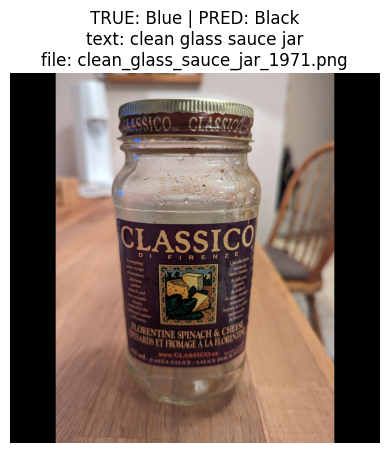

In [ ]:
mis_idx = np.where(preds != labels)[0]
print("Misclassified:", len(mis_idx), "out of", len(labels))

def show_image(path, title=""):
    img = Image.open(path).convert("RGB")
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Show up to N misclassified examples
N = 12
for i in mis_idx[:N]:
    true_name = class_names[labels[i]]
    pred_name = class_names[preds[i]]
    title = f"TRUE: {true_name} | PRED: {pred_name}\ntext: {texts[i]}\nfile: {os.path.basename(paths[i])}"
    show_image(paths[i], title)
